## Variance in Linear Regression

The goal of this notebook is to show how various levels of variance in the dataset can affect the performance of a linear regression model trained with SGD.

In [91]:
import numpy as np

SLOPE = 3.5
INTERCEPT = 7.1

"""Signal to estimate"""
def f(x: np.ndarray) -> np.ndarray:
    return x*SLOPE + INTERCEPT

coefs = np.array([
    [SLOPE],
    [INTERCEPT]
])

In [92]:
"""Generate dataset helper"""

import numpy as np

MIN = -7
MAX = 7
SEED = 777

rng = np.random.default_rng(SEED)

def generate_sample(size: int, noise: float) -> np.ndarray:
    x = rng.uniform(MIN, MAX, size)
    y = f(x) + rng.standard_normal(x.shape[0]) * noise

    return np.stack([x, y]).T

def generate_dataset(size: int, sample_size: int, noise_upto: float) -> np.ndarray:
    datasets: list[np.ndarray] = []

    for noise in np.linspace(0, noise_upto, size):
        sample = generate_sample(sample_size, noise)
        datasets.append(sample)

    return np.stack(datasets[:])

In [102]:
"""Plot data helper"""

import matplotlib.pyplot as plt

def plot_sample(X: np.ndarray, axis:int = 0) -> None:
    row = int(np.floor(np.sqrt(X.shape[axis])))
    col = int(np.ceil(X.shape[axis]/row))
    
    fig, axs = plt.subplots(row, col, figsize=(16, 7))
    axs = axs.flatten()
    
    for i, ax in enumerate(axs):
        ax.scatter(X[i, :, 0], X[i, :, 1])

    fig.tight_layout()
    plt.show()

## How data are build
 
The datasets builds with `generate_dataset` function has structuraly higher variance along `axis=0`.
Variance increases is computed generating an array of equally spaced values between `0` and `noise_upto` and adding it to the `y` values of the dataset. The higher the `noise_upto` value, the higher the variance in the dataset.

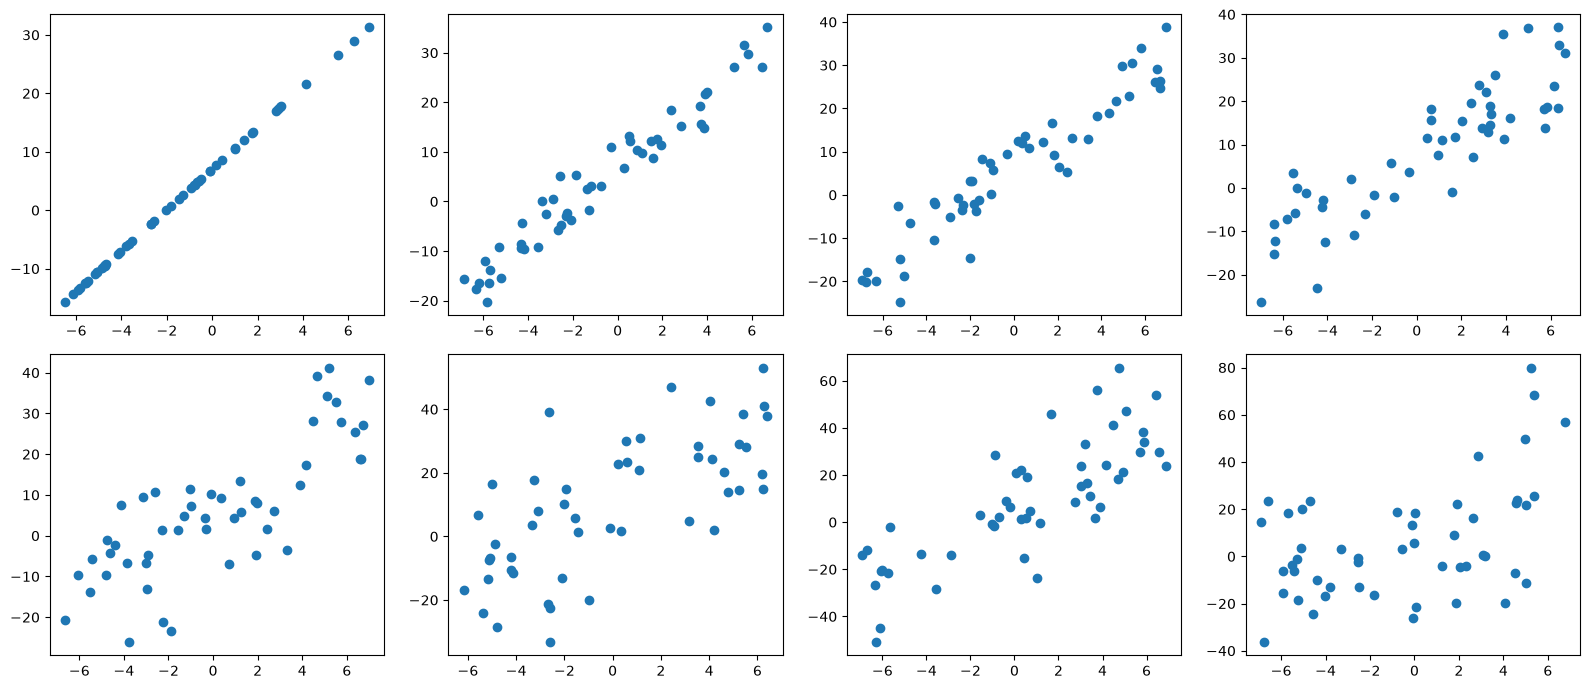

In [103]:
X = generate_dataset(size=8, sample_size=50, noise_upto=20)
plot_sample(X)